<a href="https://colab.research.google.com/github/iabad5-del/upc-ia/blob/main/SupervisedML_Classificacio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
df = pd.read_csv("/content/titanic_clean (2).csv")

In [ ]:
df

,age,fare,alone,embarked_C,embarked_Q,embarked_S,class_First,class_Second,class_Third,who_child,who_man,who_woman,survived
0,-0.544564,-0.528033,-1.143544,-0.497996,-0.283430,0.612912,-0.610933,-0.515978,0.964724,-0.342751,0.860855,-0.686803,0
1,0.573922,0.697956,-1.143544,2.008048,-0.283430,-1.631555,1.636840,-0.515978,-1.036566,-0.342751,-1.161636,1.456022,1
2,-0.264943,-0.515109,0.874475,-0.497996,-0.283430,0.612912,-0.610933,-0.515978,0.964724,-0.342751,-1.161636,1.456022,1
3,0.364206,0.349817,-1.143544,-0.497996,-0.283430,0.612912,1.636840,-0.515978,-1.036566,-0.342751,-1.161636,1.456022,1
4,0.364206,-0.512716,0.874475,-0.497996,-0.283430,0.612912,-0.610933,-0.515978,0.964724,-0.342751,0.860855,-0.686803,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
775,0.643827,-0.109211,-1.143544,-0.497996,3.528211,-1.631555,-0.610933,-0.515978,0.964724,-0.342751,-1.161636,1.456022,0
776,-0.754280,-0.092459,0.874475,-0.497996,-0.283430,0.612912,1.636840,-0.515978,-1.036566,-0.342751,-1.161636,1.456022,1
777,-0.509612,-0.217866,-1.143544,-0.497996,-0.283430,0.612912,-0.610933,-0.515978,0.964724,-0.342751,-1.161636,1.456022,0
778,-0.264943,-0.092459,0.874475,2.008048,-0.283430,-1.631555,1.636840,-0.515978,-1.036566,-0.342751,0.860855,-0.686803,1


Per tal que els classificadors puguin fer-ho sense problema, cal que el target estigui en enters. Així doncs, el deixarem sense estandarditzar.

## **Preparació de les dades**

Per començar, separem el dataset en el target, d'una banda, i les variables per altra. El target serà *y* i la resta d'atributs seran *X*.

In [ ]:
# Identify target and features
X = df.drop('survived', axis=1)
y = df['survived']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (780, 12)
Target shape: (780,)


In [ ]:
y.value_counts() # Quantes observacions hi ha de cada tipus

,count
survived,
0,458
1,322


## **Divisió de les dades: train, validation and test**

Separem el dataset (les variables i el target) en dos sub-datasets:
1.  **Train**: Per entrenar el model i ajustar-lo. Amb aquestes dades, es provaran diverses configuracions d'hiperparametres, per veure quina és la que proporciona millors resultats.
2.  **Test**: Per avaluar el model un cop aquest ja ha estat entrenat. Les dades d'aquest subset seran noves per al model.

Durant l'entrenament del model, usarem la funció `StratifiedKFold`. Aquesta funció el que fa és fer una primera validació del model fent ús de la tècnica cross-validation. Amb aquesta, el que es fa és una divisió de les dades d'entrenament en K parts, de manera que una s'usa com a set de **validació** i les K-1 restants com a set d'entrenament propi. Aquest mètode permet fer una primera avaluació del model, abans de les dades de test, prenent com a resultat total la mitjana de cadascun dels folds.

In [ ]:
# Divisió de les dades en train i test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Conjunt de train (shape): {X_train.shape}, {y_train.shape}")
print(f"Conjunt de test (shape): {X_test.shape}, {y_test.shape}")

Conjunt de train (shape): (624, 12), (624,)
Conjunt de test (shape): (156, 12), (156,)


## **Algorismes de classificació**

### 1. Logistic regression

In [ ]:
# Pipeline
pipeline = Pipeline([
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Paràmetres a provar
param_grid = {
    'selector__k': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 'all']
}

# Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Grid Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Entrenar
grid_search.fit(X_train, y_train)

print("==========================================")
print("Millors paràmetres:")
print(grid_search.best_params_)
print("==========================================")

print("\nMillor RMSE (CV):")
print(-grid.best_score_)
print("==========================================")

best_model = grid_search.best_estimator_
selected_features = X_train.columns[
    best_model.named_steps['selector'].get_support()
]

print("Variables seleccionades:")
print(selected_features)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Millors paràmetres:
{'selector__k': 10}

Millor accuracy CV:
0.7773032258064516
Variables seleccionades:
Index(['fare', 'alone', 'embarked_C', 'embarked_S', 'class_First',
       'class_Second', 'class_Third', 'who_child', 'who_man', 'who_woman'],
      dtype='object')


Accuracy de test: 0.7948717948717948
              precision    recall  f1-score   support

           0       0.80      0.87      0.83        92
           1       0.79      0.69      0.73        64

    accuracy                           0.79       156
   macro avg       0.79      0.78      0.78       156
weighted avg       0.79      0.79      0.79       156



<Axes: >

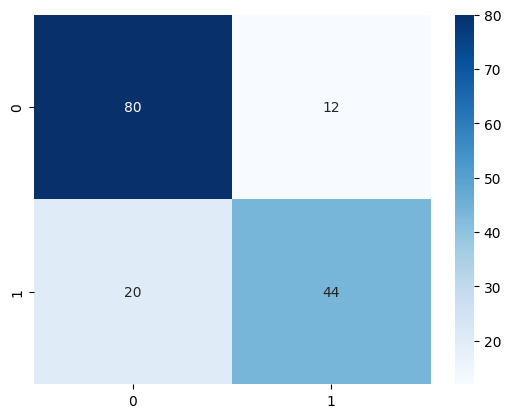

In [ ]:
# Predicció amb dades de test
y_test_pred = best_model.predict(X_test)

print("Accuracy de test:", accuracy_score(y_test, y_test_pred))
print("==========================================")

print(classification_report(y_test, y_test_pred))

cf_matrix = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cf_matrix, annot=True, cmap='Blues')

### 2. Naive Bayes

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold


# Pipeline
pipeline = Pipeline([
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', GaussianNB())
])


# Paràmetres a provar
param_grid = {
    'selector__k': [2, 5, 8, 10, 'all']
}


# Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Grid Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)


# Entrenar
grid_search.fit(X_train, y_train)


print("==========================================")
print("Millors paràmetres:")
print(grid_search.best_params_)
print("==========================================")

print("\nMillor accuracy CV:")
print(grid_search.best_score_)
print("==========================================")


# Millor model
best_model = grid_search.best_estimator_


# Variables seleccionades
selected_features = X_train.columns[
    best_model.named_steps['selector'].get_support()
]

print("Variables seleccionades:")
print(selected_features)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Millors paràmetres:
{'selector__k': 2}

Millor accuracy CV:
0.770941935483871
Variables seleccionades:
Index(['who_man', 'who_woman'], dtype='object')


Accuracy de test: 0.7628205128205128
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        92
           1       0.71      0.70      0.71        64

    accuracy                           0.76       156
   macro avg       0.75      0.75      0.75       156
weighted avg       0.76      0.76      0.76       156



<Axes: >

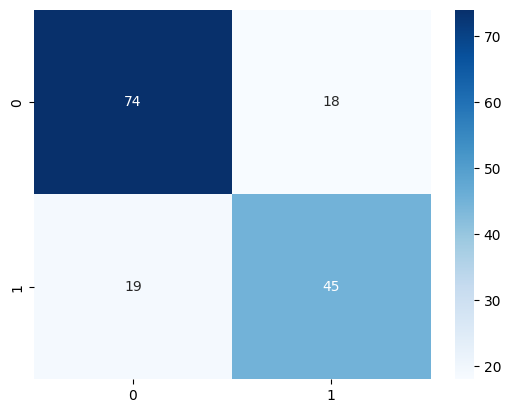

In [ ]:
# Predicció amb dades de test
y_test_pred = best_model.predict(X_test)

print("Accuracy de test:", accuracy_score(y_test, y_test_pred))
print("==========================================")

print(classification_report(y_test, y_test_pred))

cf_matrix = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cf_matrix, annot=True, cmap='Blues')

### 3. KNN

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold


# Pipeline
pipeline = Pipeline([
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', KNeighborsClassifier())
])


# Paràmetres a provar
param_grid = {
    'selector__k': [2, 5, 8, 10, 'all'],
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 15]
    # 'classifier__metric': ['euclidean', 'manhattan'] Diferents mètodes de calcular distàncies
}


# Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Grid Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)


# Entrenar
grid_search.fit(X_train, y_train)


print("==========================================")
print("Millors paràmetres:")
print(grid_search.best_params_)
print("==========================================")

print("\nMillor accuracy CV:")
print(grid_search.best_score_)
print("==========================================")


# Millor model
best_model = grid_search.best_estimator_


# Variables seleccionades
selected_features = X_train.columns[
    best_model.named_steps['selector'].get_support()
]

print("Variables seleccionades:")
print(selected_features)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Millors paràmetres:
{'classifier__n_neighbors': 15, 'selector__k': 5}

Millor accuracy CV:
0.8157677419354838
Variables seleccionades:
Index(['fare', 'class_First', 'class_Third', 'who_man', 'who_woman'], dtype='object')


Accuracy de test: 0.7884615384615384
              precision    recall  f1-score   support

           0       0.78      0.90      0.83        92
           1       0.82      0.62      0.71        64

    accuracy                           0.79       156
   macro avg       0.80      0.76      0.77       156
weighted avg       0.79      0.79      0.78       156



<Axes: >

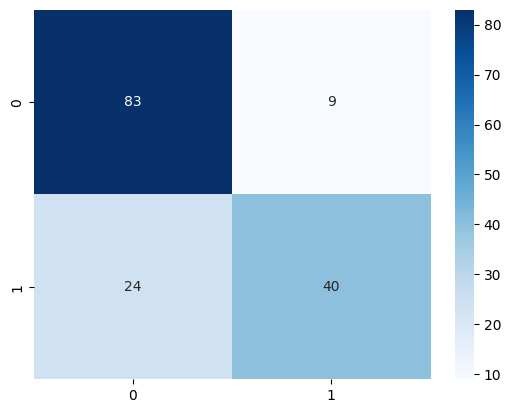

In [ ]:
# Predicció amb dades de test
y_test_pred = best_model.predict(X_test)

print("Accuracy de test:", accuracy_score(y_test, y_test_pred))
print("==========================================")

print(classification_report(y_test, y_test_pred))

cf_matrix = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cf_matrix, annot=True, cmap='Blues')

### 4. Decision tree

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold


# Pipeline
pipeline = Pipeline([
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])


# Paràmetres a provar
param_grid = {
    'selector__k': [2, 5, 8, 10, 'all'],
    'classifier__criterion': ['gini', 'entropy', 'log_loss'],
    'classifier__max_depth': [None, 3, 5, 7, 10, 15],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__min_impurity_decrease': [0.0, 0.1, 0.2]
}


# Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Grid Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)


# Entrenar
grid_search.fit(X_train, y_train)


print("==========================================")
print("Millors paràmetres:")
print(grid_search.best_params_)
print("==========================================")

print("\nMillor accuracy CV:")
print(grid_search.best_score_)
print("==========================================")


# Millor model
best_model = grid_search.best_estimator_


# Variables seleccionades
selected_features = X_train.columns[
    best_model.named_steps['selector'].get_support()
]

print("Variables seleccionades:")
print(selected_features)

Fitting 5 folds for each of 2430 candidates, totalling 12150 fits
Millors paràmetres:
{'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_impurity_decrease': 0.0, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2, 'selector__k': 5}

Millor accuracy CV:
0.8205806451612905
Variables seleccionades:
Index(['fare', 'class_First', 'class_Third', 'who_man', 'who_woman'], dtype='object')


Accuracy de test: 0.7948717948717948
              precision    recall  f1-score   support

           0       0.77      0.92      0.84        92
           1       0.85      0.61      0.71        64

    accuracy                           0.79       156
   macro avg       0.81      0.77      0.78       156
weighted avg       0.80      0.79      0.79       156



<Axes: >

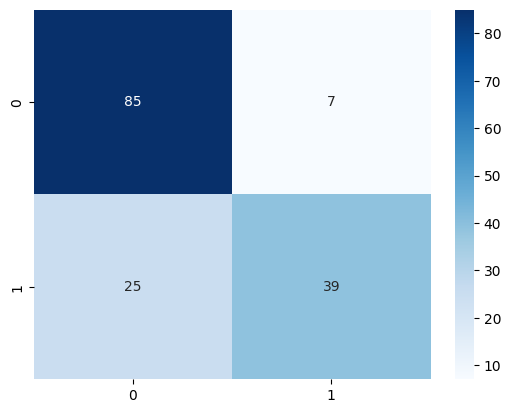

In [ ]:
# Predicció amb dades de test
y_test_pred = best_model.predict(X_test)

print("Accuracy de test:", accuracy_score(y_test, y_test_pred))
print("==========================================")

print(classification_report(y_test, y_test_pred))

cf_matrix = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cf_matrix, annot=True, cmap='Blues')

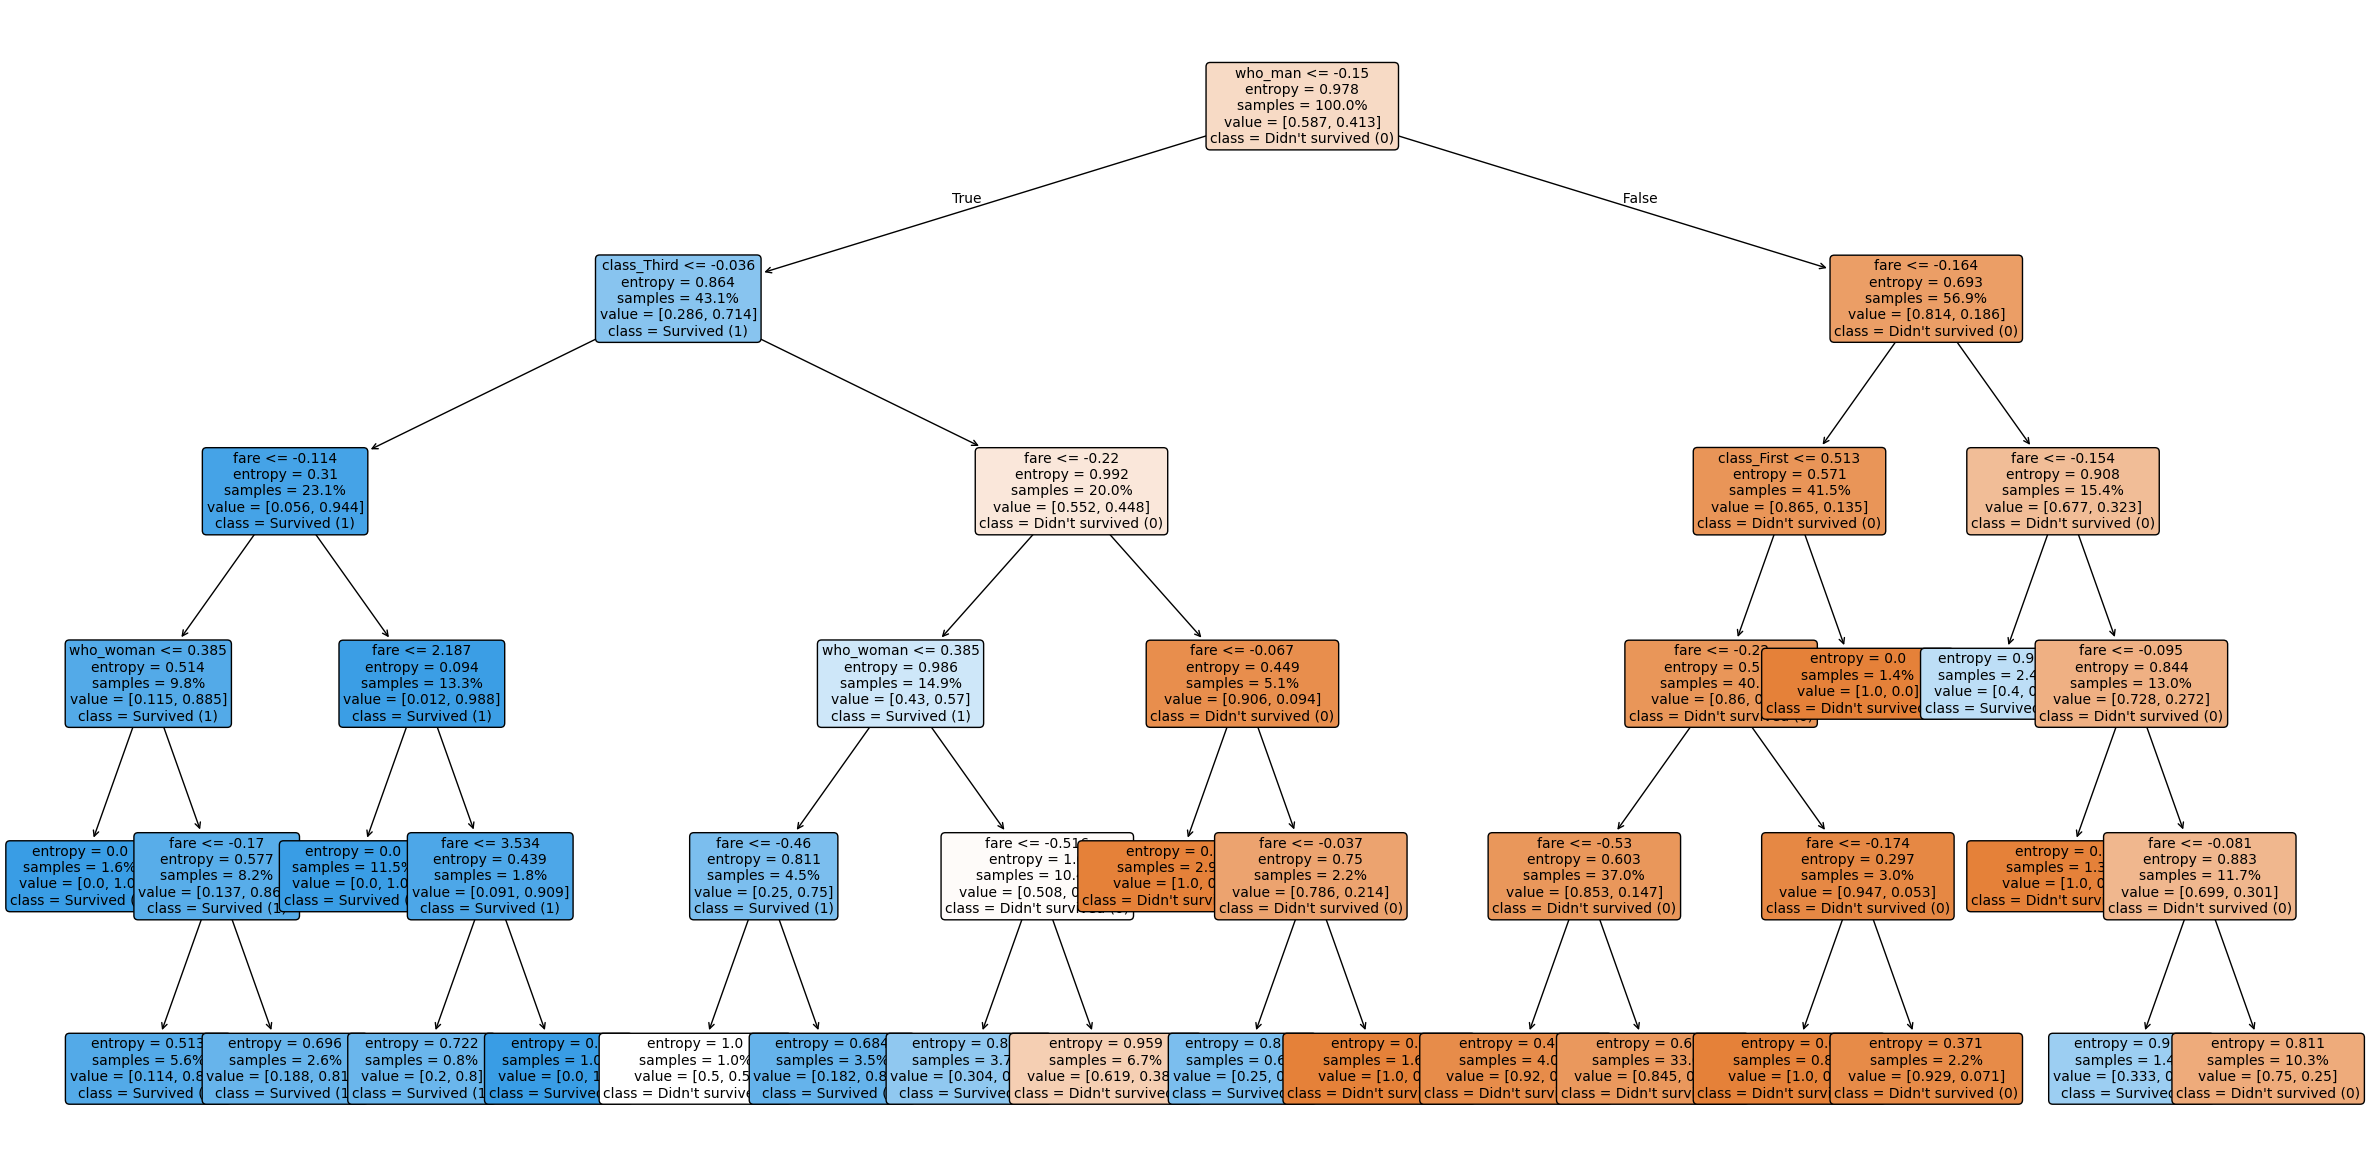

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt
plt.figure(figsize=(30,15))
tree.plot_tree(best_model.named_steps['classifier'], feature_names=selected_features, class_names=["Didn't survived (0)", 'Survived (1)'], filled=True, rounded=True, impurity=True, proportion=True, fontsize=10)
plt.show()

### 5. Support vector machine

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold


# Pipeline
pipeline = Pipeline([
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', SVC())
])


# Paràmetres a provar
param_grid = {
    'selector__k': [2, 5, 8, 10, 'all'],
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'classifier__degree': [2, 3, 4]
}


# Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Grid Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)


# Entrenar
grid_search.fit(X_train, y_train)


print("==========================================")
print("Millors paràmetres:")
print(grid_search.best_params_)
print("==========================================")

print("\nMillor accuracy CV:")
print(grid_search.best_score_)
print("==========================================")


# Millor model
best_model = grid_search.best_estimator_


# Variables seleccionades
selected_features = X_train.columns[
    best_model.named_steps['selector'].get_support()
]

print("Variables seleccionades:")
print(selected_features)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Millors paràmetres:
{'classifier__C': 10, 'classifier__degree': 3, 'classifier__kernel': 'poly', 'selector__k': 5}

Millor accuracy CV:
0.8125935483870969
Variables seleccionades:
Index(['fare', 'class_First', 'class_Third', 'who_man', 'who_woman'], dtype='object')


Accuracy de test: 0.7884615384615384
              precision    recall  f1-score   support

           0       0.75      0.97      0.84        92
           1       0.92      0.53      0.67        64

    accuracy                           0.79       156
   macro avg       0.83      0.75      0.76       156
weighted avg       0.82      0.79      0.77       156



<Axes: >

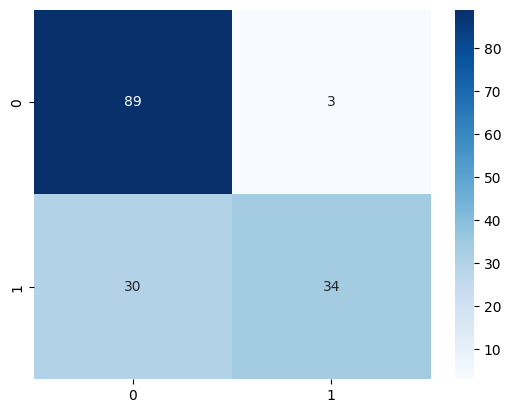

In [ ]:
y_test_pred = best_model.predict(X_test)

print("Accuracy de test:", accuracy_score(y_test, y_test_pred))
print("==========================================")

print(classification_report(y_test, y_test_pred))

cf_matrix = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cf_matrix, annot=True, cmap='Blues')